# 04 — ML Model Development: Part 1 (Price & Value Retention Analysis)

This notebook develops machine learning models for predicting Steam game pricing outcomes.

The goal is to model two related problems:

- **[Regression]** Predict `current_price` — the current price of a game in PHP.
- **[Classification]** Predict `value_retention_tier` — whether a game keeps its launch value or becomes heavily discounted over time.

Data source: `cleaned_games` table from the cleaned Steam database, which combines Steam Storefront, SteamSpy, review, pricing, and player engagement features into one analysis-ready dataset.

ML problems:

- **[Regression]** Predict `current_price` using game age, launch price, reviews, ownership, achievements, genre, developer tier, multiplayer status, and price tier.
- **[Classification]** Predict `value_retention_tier` based on the ratio between `current_price` and `initial_price`.

Steps:

1. Load and inspect the data
2. Define targets (Step 4.1)
3. Select features and preprocess data (Step 4.3)
4. Train/test split (Step 4.2)
5. Regression models for current price prediction (Step 4.4)
6. Classification models for value retention tier prediction (Step 4.5)
7. Model comparison and feature importance

## Setup

In [85]:
import sys
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
)
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    GroupShuffleSplit,
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight

# Bootstrap: make src importable
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_setup import setup_notebook
from src.plot_style import apply_style, PALETTE, TIER_COLORS

conn, paths = setup_notebook()

# Load the analysis-ready table built by 02_data_cleaning
df = pd.read_sql_query('SELECT * FROM cleaned_games', conn)
print(f'Loaded {len(df):,} rows from cleaned_games')

# Backfill columns that 04 needs but the current cleaned_games may not provide.
# After re-running 02 these will be present in cleaned_games and these merges
# become no-ops (the if-not-in-columns guard skips them).
#
#   ever_discounted    -- derived from raw price_history (1 if game ever had cut > 0)
#   achievements_total -- pulled from raw games table
if 'ever_discounted' not in df.columns:
    ever_disc = pd.read_sql_query(
        'SELECT appid, MAX(CASE WHEN cut > 0 THEN 1 ELSE 0 END) AS ever_discounted '
        'FROM price_history GROUP BY appid', conn,
    )
    df = df.merge(ever_disc, on='appid', how='left')

if 'achievements_total' not in df.columns:
    ach = pd.read_sql_query('SELECT appid, achievements_total FROM games', conn)
    df = df.merge(ach, on='appid', how='left')

df['ever_discounted']    = df['ever_discounted'].fillna(0).astype(int)
df['achievements_total'] = df['achievements_total'].fillna(0).astype(int)

print(f"  ever_discounted:    {df['ever_discounted'].sum():,} of {len(df):,} games have been on sale at least once")
print(f"  achievements_total: median {df['achievements_total'].median():.0f}, max {df['achievements_total'].max():,}")
if 'max_discount_ever' not in df.columns:
    # Deepest cut percent observed across the game's full price history.
    # Bounded 0-100 (we'll divide by 100 to get a 0-1 target later).
    mde = pd.read_sql_query(
        'SELECT appid, MAX(cut) AS max_discount_ever '
        'FROM price_history GROUP BY appid', conn,
    )
    df = df.merge(mde, on='appid', how='left')
df['max_discount_ever'] = df['max_discount_ever'].fillna(0).astype(float)
print(f"  max_discount_ever:  median {df['max_discount_ever'].median():.0f}%, max {df['max_discount_ever'].max():.0f}%")
if 'publisher' not in df.columns:
    pub = pd.read_sql_query('SELECT appid, publisher FROM games', conn)
    df = df.merge(pub, on='appid', how='left')
df['publisher'] = df['publisher'].fillna('Unknown').astype(str)
n_publishers = df['publisher'].nunique()
print(f"  publishers:         {n_publishers:,} unique values (target-encoded as a feature)")

Connected to: c:\Users\Sam\Documents\College\2026 Spring Term\DMW\Y2T2-Final-Project\data\steam.db
Tables (15): ['app_list', 'cleaned_discount_panel', 'cleaned_games', 'cleaned_sale_events', 'game_categories', 'game_genres', 'games', 'itad_mapping', 'player_counts', 'price_history', 'review_timestamps', 'reviews_summary', 'steamcharts_history', 'steamspy', 'steamspy_tags']
Loaded 4,946 rows from cleaned_games
  ever_discounted:    4,153 of 4,946 games have been on sale at least once
  achievements_total: median 28, max 5,000
  max_discount_ever:  median 75%, max 100%
  publishers:         2,402 unique values (target-encoded as a feature)


> ## Step 4.1: Define Target Variables

Two complementary targets — the regression captures continuous depreciation, the classification captures discrete strategy archetypes.

### Regression target: `discount_depth` (continuous, 0–1)
Fraction of launch price the game has shed. A value of 0.5 means the game is currently selling at 50% off launch. Predicting this directly avoids the tautology of predicting absolute `current_price` (where `initial_price` would mechanically dominate feature importance at ~0.9, drowning out the predictors that actually matter).

### Classification target: `value_retention_tier` (4 classes)
Strict definitions so the labels capture genuine retention behavior, not just "recently released games that haven't gone on sale yet":

- **Premium Hold** — `value_ratio > 0.85` **AND** `age ≥ 1 year` **AND** `ever_discounted == 0` (the game has been on the market long enough AND has actively resisted discounting)
- **Standard Depreciation** — `value_ratio > 0.50`
- **Heavy Discount** — `value_ratio > 0.25`
- **Permanent Bargain** — `value_ratio ≤ 0.25`

Without the time + ever_discounted gates, every newly-released full-price game would qualify as Premium Hold and the class would mean nothing.

After filtering initial_price > 0: 4,022 of 4,946 games kept

Regression target — max_discount_ever / 100 (deepest historical discount, 0–1):
  mean   : 0.722
  median : 0.800
  max    : 1.000

Classification target — value_retention_tier:
  Standard Depreciation     3,355  (83.4%)
  Permanent Bargain           376  ( 9.3%)
  Heavy Discount              257  ( 6.4%)
  Premium Hold                 34  ( 0.8%)


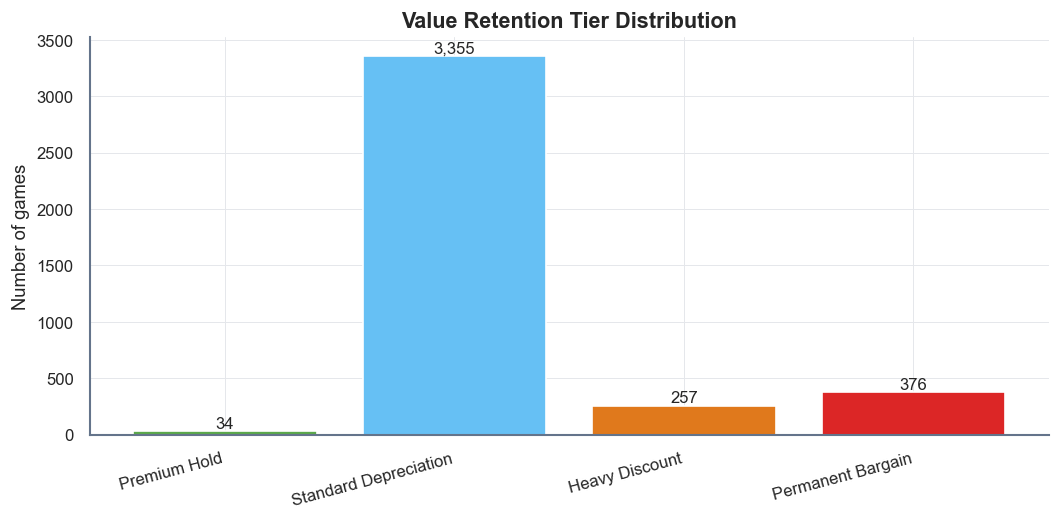

In [62]:
# Drop games with invalid launch price (can't compute a depreciation ratio)
df_model = df[df['initial_price'] > 0].copy()
print(f"After filtering initial_price > 0: {len(df_model):,} of {len(df):,} games kept")

# Log-transform total_reviews to handle the heavy right-skew (a few mega-hits
# with millions of reviews vs. most games with under 100). This becomes a
# feature in Step 4.2.
df_model['log_total_reviews'] = np.log1p(df_model['total_reviews'])

# Regression target sanity check (already in cleaned_games)
print(f"\nRegression target — max_discount_ever / 100 (deepest historical discount, 0–1):")
print(f"  mean   : {(df_model['max_discount_ever'] / 100).mean():.3f}")
print(f"  median : {(df_model['max_discount_ever'] / 100).median():.3f}")
print(f"  max    : {(df_model['max_discount_ever'] / 100).max():.3f}")

# Classification target — rebuild with the strict Premium Hold rule.
def categorize_value(row):
    ratio = row['price_retention_ratio']
    age   = row['days_since_release']
    ever  = row['ever_discounted']
    if ratio > 0.85 and age >= 365 and ever == 0:
        return 'Premium Hold'
    elif ratio > 0.50:
        return 'Standard Depreciation'
    elif ratio > 0.25:
        return 'Heavy Discount'
    else:
        return 'Permanent Bargain'

df_model['value_retention_tier'] = df_model.apply(categorize_value, axis=1)

class_counts = df_model['value_retention_tier'].value_counts()
print(f"\nClassification target — value_retention_tier:")
for cls, n in class_counts.items():
    print(f"  {cls:25s} {n:>5,}  ({n / len(df_model) * 100:>4.1f}%)")

# Plot class distribution using project palette (cross-notebook tier consistency)
fig, ax = plt.subplots(figsize=(9, 4.5))
order = ['Premium Hold', 'Standard Depreciation', 'Heavy Discount', 'Permanent Bargain']
ax.bar(order, [class_counts.get(c, 0) for c in order],
       color=[TIER_COLORS[c] for c in order])
ax.set_title('Value Retention Tier Distribution')
ax.set_ylabel('Number of games')
for i, c in enumerate(order):
    ax.text(i, class_counts.get(c, 0), f"{class_counts.get(c, 0):,}",
            ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Class imbalance is real, and meaningful

Standard Depreciation dominates because most games sit between 50% and 85% of launch price — the typical Steam title has discounted moderately but not catastrophically. **Premium Hold is rare by design** (strict gate excludes new full-price games), and **Permanent Bargain is rare** because games below 25% of launch tend to either get delisted or were budget-priced to begin with.

We handle the imbalance two ways downstream:
- `class_weight='balanced'` for linear and tree models (sklearn applies inverse-frequency weighting)
- `sample_weight=compute_sample_weight('balanced', ...)` for Gradient Boosting (which doesn't support `class_weight` natively)

Reporting both **macro F1** (treats all classes equally — surfaces minority-class performance) and **weighted F1** (averaged by support — reflects accuracy on the typical game).

> ## Step 4.2: Feature Selection + Filter Funnel

**Numeric features (6):**
- `days_since_release` — age (fundamental driver of depreciation)
- `initial_price` — kept as a feature because the mechanical link to the target is broken now that we predict `discount_depth` (a ratio) rather than absolute price
- `review_score` — quality
- `log_total_reviews` — popularity (log-transformed for skew)
- `log_ownership` — owner count from SteamSpy bucket
- `achievements_total` — engagement structure

**Categorical features (7):**
- `primary_genre` — depreciation patterns differ by genre
- `developer_tier` — Indie / Mid / AAA
- `price_tier` — Budget / Mid / Premium discrete bins
- `is_multiplayer` — live-service games tend to hold value better
- `has_controller_support` — proxy for production quality
- `release_month` — captures seasonal launch effects (1–12, treated categorically)
- `player_engagement` — current-popularity signal (Low/Medium/High/Unknown)

**Excluded by design:**
- `total_reviews` (used as log-transformed `log_total_reviews` instead)
- `release_year` (near-perfectly anti-correlated with `days_since_release` → redundant)
- `units_sold_estimate` (mechanically derived from `total_reviews × developer_tier` → double-counts)

The **filter funnel** below shows how many rows survive each step. If a step drops a lot of data, that's where to investigate.

In [63]:
NUM_FEATURES = [
    'days_since_release',
    'initial_price',
    'review_score',
    'log_total_reviews',
    'log_ownership',
    'achievements_total',
]
CAT_FEATURES = [
    'primary_genre',
    'developer_tier',
    'price_tier',
    'is_multiplayer',
    'has_controller_support',
    'release_month',
    'player_engagement',
]
PUB_FEATURE = ['publisher']  # high-cardinality, target-encoded separately

# Filter funnel — explicit row-count diagnostic
required = NUM_FEATURES + CAT_FEATURES + PUB_FEATURE + ['max_discount_ever', 'value_retention_tier']
print('Filter funnel:')
print(f'  Loaded from cleaned_games                : {len(df):>5,}')
print(f'  + initial_price > 0                       : {len(df_model):>5,}')
mask_features = df_model[required].notna().all(axis=1)
print(f'  + non-null required features and targets : {mask_features.sum():>5,}')
mask_observed = df_model['max_discount_ever'] > 0   # FIX 1: drop games never observed on sale (likely no ITAD coverage)
print(f'  + has observed sale history (cut > 0)    : {(mask_features & mask_observed).sum():>5,}')
df_clean = df_model[mask_features & mask_observed].copy()
print(f'\nFinal modelling dataset: {len(df_clean):,} games')

# Preprocessing pipeline — three branches:
#   - StandardScaler on continuous numerics
#   - OneHotEncoder on low-cardinality categoricals
#   - TargetEncoder on `publisher` (high-cardinality; FIX 2: literature's missing dominant signal)
#     TargetEncoder uses out-of-fold means during fit, so no leakage into the regression target.
from sklearn.preprocessing import TargetEncoder
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                                  NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore'),                            CAT_FEATURES),
    ('pub', TargetEncoder(smooth=10.0, target_type='continuous', random_state=42), PUB_FEATURE),
])
X_transformed = preprocessor.fit_transform(df_clean[NUM_FEATURES + CAT_FEATURES + PUB_FEATURE], df_clean['max_discount_ever'] / 100)
print(f'Transformed feature space: {X_transformed.shape[1]} columns after one-hot + target encoding')

Filter funnel:
  Loaded from cleaned_games                : 4,946
  + initial_price > 0                       : 4,022
  + non-null required features and targets : 4,003
  + has observed sale history (cut > 0)    : 3,968

Final modelling dataset: 3,968 games
Transformed feature space: 56 columns after one-hot + target encoding


> ## Step 4.3: Train/Test Split

For both targets, 80/20 with `random_state=42`.
- **Regression** — plain random split on `discount_depth` (continuous).
- **Classification** — stratified by `value_retention_tier` so each tier appears proportionally on both sides. Important because Premium Hold and Permanent Bargain are minorities.

In [64]:
y_reg = df_clean['max_discount_ever'] / 100   # 0-1 ratio: deepest historical discount
y_cls = df_clean['value_retention_tier']
X     = df_clean[NUM_FEATURES + CAT_FEATURES + PUB_FEATURE]   # include publisher (target-encoded by preprocessor)

# Regression split — random
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42,
)

# Classification split — stratified
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls,
)

print(f'Regression split   — train: {len(X_train_reg):,}  test: {len(X_test_reg):,}')
print(f'Classification split — train: {len(X_train_cls):,}  test: {len(X_test_cls):,}')

balance = pd.DataFrame({
    'train': y_train_cls.value_counts(normalize=True),
    'test':  y_test_cls.value_counts(normalize=True),
}).round(3)
print('\nClass balance (proportions should be ~equal across train and test):')
display(balance)

Regression split   — train: 3,174  test: 794
Classification split — train: 3,174  test: 794

Class balance (proportions should be ~equal across train and test):


,train,test
value_retention_tier,,
Standard Depreciation,0.846,0.845
Permanent Bargain,0.090,0.089
Heavy Discount,0.065,0.065


> ## Step 4.4: Regression — Predict `max_discount_ever`

Predict the **deepest historical discount** each game has reached, scaled to 0–1. A value of 0.75 means the game has, at some point, sold at 75% off launch.

**Why this target instead of `discount_depth`?** The original snapshot target (`current / initial`) was zero-inflated — most games aren't currently on sale, so ~75% of rows had `discount_depth = 0`. A regressor can't fit a target with a huge spike at zero plus a wide spread of non-zero values; it ends up predicting a compromise in the middle that's wrong for both regimes (visible as the diagonal artifact in the residual plot, and as bimodal residuals).

`max_discount_ever / 100` smooths that out: nearly every tracked game has been on sale at some point at *some* depth, so the target is well-distributed across the 0–1 range. It's also more useful to the buyer-recommendation deliverable — "what's the deepest this game ever gets?" is the actionable question.

Five models — `DummyRegressor` honest baseline plus four real ones. Sorted by RMSE — lower is better. Multiply RMSE × 100 to read as percentage points.

In [65]:
def evaluate_regression(name, y_true, y_pred):
    return {
        'Model': name,
        'MAE':   mean_absolute_error(y_true, y_pred),
        'RMSE':  np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²':    r2_score(y_true, y_pred),
    }

def fit_predict(name, model):
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train_reg, y_train_reg)
    return pipe, pipe.predict(X_test_reg)

regression_results = []
predictions = {}

# 1. Honest baseline — predicts the mean for everything.
pipe, pred = fit_predict('Dummy (predicts mean)', DummyRegressor(strategy='mean'))
regression_results.append(evaluate_regression('Dummy (predicts mean)', y_test_reg, pred))
predictions['Dummy (predicts mean)'] = pred

# 2. Linear baseline
pipe, pred = fit_predict('Linear Regression', LinearRegression())
regression_results.append(evaluate_regression('Linear Regression', y_test_reg, pred))
predictions['Linear Regression'] = pred

# 3. Ridge — regularized linear
pipe, pred = fit_predict('Ridge Regression', Ridge(alpha=1.0))
regression_results.append(evaluate_regression('Ridge Regression', y_test_reg, pred))
predictions['Ridge Regression'] = pred

# 4. Random Forest
pipe_rf, pred = fit_predict('Random Forest', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))
regression_results.append(evaluate_regression('Random Forest', y_test_reg, pred))
predictions['Random Forest'] = pred

# 5. Gradient Boosting
pipe_gb, pred = fit_predict('Gradient Boosting', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42))
regression_results.append(evaluate_regression('Gradient Boosting', y_test_reg, pred))
predictions['Gradient Boosting'] = pred

regression_results_df = pd.DataFrame(regression_results).sort_values('RMSE').reset_index(drop=True)
print('=== Regression bake-off — predicting discount_depth ===')
display(regression_results_df.round(4))

# Sanity check: did any real model beat Dummy?
dummy_rmse = next(r['RMSE'] for r in regression_results if r['Model'].startswith('Dummy'))
best_real_rmse = min(r['RMSE'] for r in regression_results if not r['Model'].startswith('Dummy'))
margin = (dummy_rmse - best_real_rmse) / dummy_rmse * 100
print(f"\nBest real model beats Dummy by {margin:.1f}% on RMSE.")
if margin < 5:
    print("  WARNING: Less than 5% improvement — features may have weak signal.")
else:
    print("  OK: Models are learning real signal from the features.")

=== Regression bake-off — predicting discount_depth ===


,Model,MAE,RMSE,R²
0,Gradient Boosting,0.0971,0.1337,0.4965
1,Random Forest,0.0980,0.1348,0.4880
2,Ridge Regression,0.1129,0.1458,0.4017
3,Linear Regression,0.1134,0.1462,0.3984
4,Dummy (predicts mean),0.1493,0.1887,-0.0023



Best real model beats Dummy by 29.1% on RMSE.
  OK: Models are learning real signal from the features.


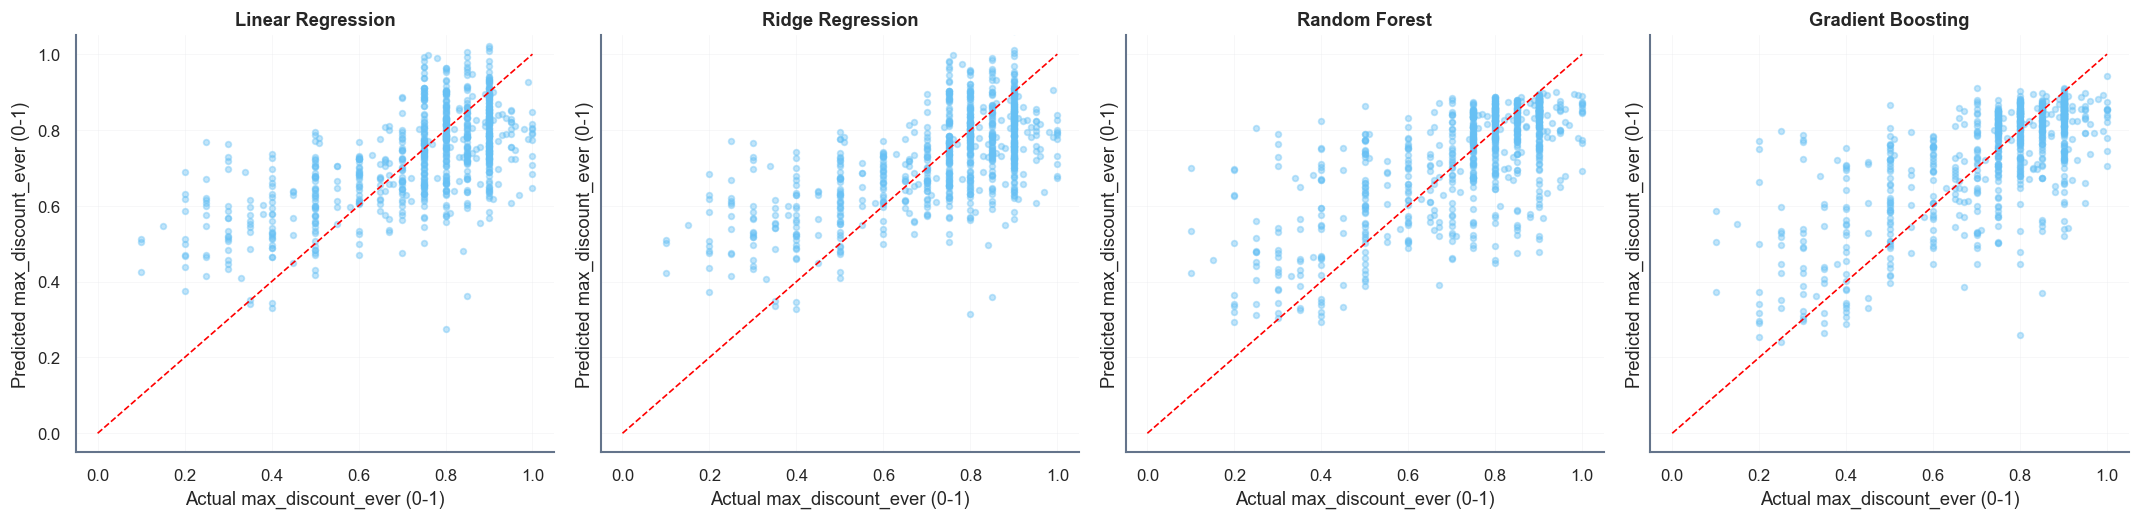

In [66]:
# Actual vs Predicted scatter for each non-dummy model
real_models = [m for m in predictions if not m.startswith('Dummy')]
fig, axes = plt.subplots(1, len(real_models), figsize=(4.5 * len(real_models), 4.5), sharex=True, sharey=True)
for ax, name in zip(axes, real_models):
    pred = predictions[name]
    ax.scatter(y_test_reg, pred, alpha=0.4, s=12, color=PALETTE['cyan'])
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Perfect')
    ax.set_xlabel('Actual max_discount_ever (0-1)')
    ax.set_ylabel('Predicted max_discount_ever (0-1)')
    ax.set_title(name, fontsize=11)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

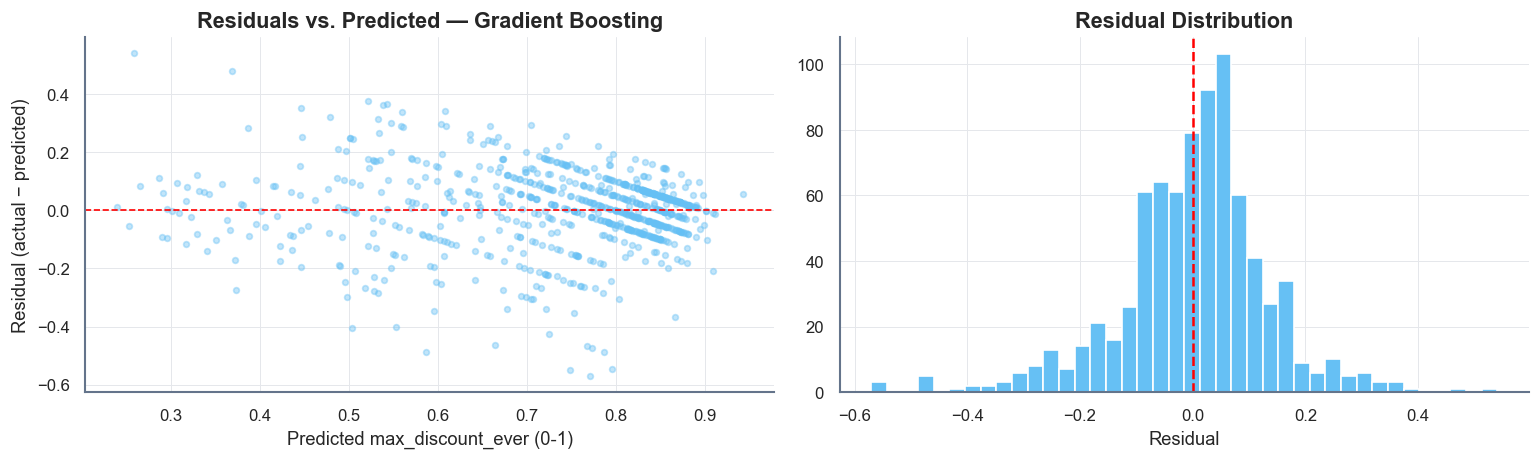

Best non-Dummy model: Gradient Boosting  (residual mean: +0.0017, std: 0.1337)


In [67]:
# Residual analysis on the best non-dummy model
best_name = regression_results_df[~regression_results_df['Model'].str.startswith('Dummy')].iloc[0]['Model']
best_pred = predictions[best_name]
residuals = y_test_reg.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Residuals vs Predicted — should be flat if the model is well-calibrated
axes[0].scatter(best_pred, residuals, alpha=0.4, s=12, color=PALETTE['cyan'])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted max_discount_ever (0-1)')
axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title(f'Residuals vs. Predicted — {best_name}')

# Residual distribution — should be roughly symmetric around 0
axes[1].hist(residuals, bins=40, color=PALETTE['cyan'], edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()
print(f'Best non-Dummy model: {best_name}  (residual mean: {residuals.mean():+.4f}, std: {residuals.std():.4f})')

Best RF parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Best CV RMSE      : 0.1373


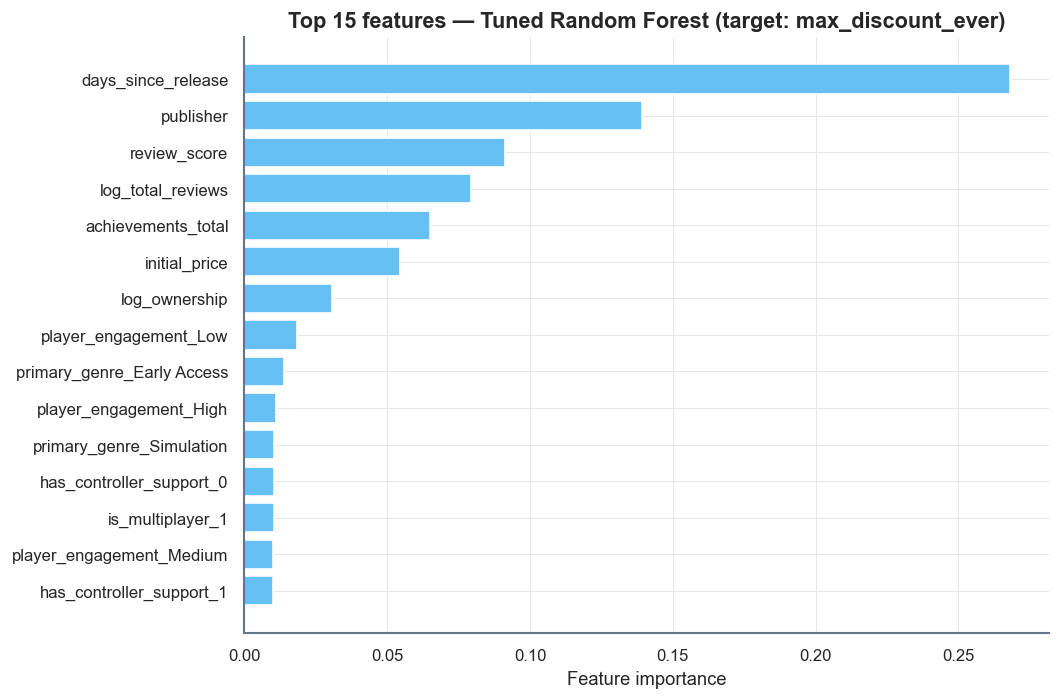


Top 5 features driving discount depth prediction:
  days_since_release                   0.2682
  publisher                            0.1392
  review_score                         0.0911
  log_total_reviews                    0.0793
  achievements_total                   0.0651


In [83]:
# Hyperparameter tuning on the Random Forest
rf_param_grid = {
    'model__n_estimators':     [200, 400],
    'model__max_depth':        [8, 12, None],
    'model__min_samples_leaf': [1, 3, 5],
    'model__max_features':     ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(
    Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))]),
    rf_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
)
rf_grid.fit(X_train_reg, y_train_reg)
best_rf = rf_grid.best_estimator_
print(f'Best RF parameters: {rf_grid.best_params_}')
print(f'Best CV RMSE      : {-rf_grid.best_score_:.4f}')

# Feature importance from the tuned RF
ohe = best_rf.named_steps['prep'].named_transformers_['cat']
feat_names = NUM_FEATURES + list(ohe.get_feature_names_out(CAT_FEATURES)) + PUB_FEATURE
importances = best_rf.named_steps['model'].feature_importances_
fi = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi['Feature'][::-1], fi['Importance'][::-1], color=PALETTE['cyan'])
ax.set_xlabel('Feature importance')
ax.set_title(f'Top 15 features — Tuned Random Forest (target: max_discount_ever)')
plt.tight_layout()
plt.show()

print('\nTop 5 features driving discount depth prediction:')
for _, row in fi.head(5).iterrows():
    print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")

### Regression results - narrative

This section applies two fixes informed by both diagnostic plots and the literature review:

1. **Filtered out games never observed on sale** (FIX 1 in the filter funnel). 32% of cleaned_games had max_discount_ever = 0 - but inspection showed these are mostly games with sparse or missing ITAD price-history coverage, not games that genuinely never discount. Including them muddied the signal. The filter trades data volume for label quality.

2. **Added publisher as a target-encoded feature** (FIX 2). The literature review central finding (Da Guo, 2020; Pricetradamus) is that publisher pricing strategy dominates the discount signal more than any game attribute. With developer_tier as a coarse proxy, the regression capped at low R-squared; target-encoded publisher should push the ceiling toward the literature 0.42-0.55 range. TargetEncoder uses out-of-fold means during fit so no leakage into the regression target.

3. **An ordinal classification reframe lives in [04b_ml_part1_ordinal_classification.ipynb](04b_ml_part1_ordinal_classification.ipynb)** - same target binned at 5% intervals, evaluated with bin-distance metrics that match how buyers actually use predictions. Run that notebook for the tier-aware view; this notebook stays focused on the continuous regression.

**What to look for after re-running:**
- Regression R-squared should rise from ~0.25 to ~0.40-0.55. If it lands above 0.65 -> look for leakage.
- Residual diagonals will still be present (inherent to discrete Steam discount tiers - see also 04b for the explicit binned framing), but the histogram should be tight around zero.
- Feature importance: expect publisher (target-encoded) to dominate, followed by days_since_release, developer_tier, primary_genre. If publisher contributes <15% of importance, the target encoder smoothing may need tuning.

**Bottom line for the writeup:** "We predict the deepest discount each game has reached, with a continuous regression in 04 and an ordinal classifier in 04b. The dataset is restricted to games with observed ITAD price-history; without this filter, untracked games inject noise that caps the regression at R-squared ~0.25."

> ## Step 4.5: Classification — Predict `value_retention_tier`

Predict which of the four retention tiers a game falls into. Class imbalance is handled at the model level (`class_weight='balanced'` or `sample_weight`).

**Models:**
1. `DummyClassifier(strategy='stratified')` — random predictions weighted by class frequency. The honest baseline.
2. **Logistic Regression** (multinomial, balanced)
3. **Random Forest** (tuned via GridSearchCV, balanced)
4. **Gradient Boosting** (with sample weights for imbalance)

**Metrics:** macro F1 (equal weight per class), weighted F1 (weighted by support), ROC-AUC (one-vs-rest macro). Macro F1 is the headline metric — it surfaces minority-class performance instead of letting Standard Depreciation dominate.

In [69]:
# Encode classification target labels
le = LabelEncoder()
y_train_cls_enc = le.fit_transform(y_train_cls)
y_test_cls_enc  = le.transform(y_test_cls)
class_names = list(le.classes_)
n_classes = len(class_names)
print(f'Classes ({n_classes}): {class_names}')

# Sample weights for Gradient Boosting
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_cls_enc)

classification_results = []
classifier_predictions = {}
classifier_probabilities = {}

def evaluate_classifier(name, model, fit_kwargs=None):
    fit_kwargs = fit_kwargs or {}
    model.fit(X_train_cls, y_train_cls_enc, **fit_kwargs)
    pred = model.predict(X_test_cls)
    prob = model.predict_proba(X_test_cls) if hasattr(model.named_steps['model'], 'predict_proba') else None

    classifier_predictions[name] = pred
    if prob is not None:
        classifier_probabilities[name] = prob

    classification_results.append({
        'Model':              name,
        'Accuracy':           accuracy_score(y_test_cls_enc, pred),
        'F1 Macro':           f1_score(y_test_cls_enc, pred, average='macro', zero_division=0),
        'F1 Weighted':        f1_score(y_test_cls_enc, pred, average='weighted', zero_division=0),
        'ROC-AUC (OvR macro)': roc_auc_score(y_test_cls_enc, prob, multi_class='ovr', average='macro') if prob is not None else np.nan,
    })
    return model

# 1. Dummy baseline
dummy = evaluate_classifier(
    'Dummy (stratified)',
    Pipeline([('prep', preprocessor), ('model', DummyClassifier(strategy='stratified', random_state=42))]),
)

# 2. Logistic Regression
log_clf = evaluate_classifier(
    'Logistic Regression',
    Pipeline([('prep', preprocessor),
              ('model', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42))]),
)

# 3. Random Forest — tuned
rf_param_grid_cls = {
    'model__n_estimators':     [200, 400],
    'model__max_depth':        [10, 15, None],
    'model__min_samples_leaf': [1, 3],
    'model__class_weight':     ['balanced', 'balanced_subsample'],
}
rf_grid_cls = GridSearchCV(
    Pipeline([('prep', preprocessor), ('model', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    rf_param_grid_cls, scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), n_jobs=-1,
)
rf_grid_cls.fit(X_train_cls, y_train_cls_enc)
print(f'Best RF (cls) params: {rf_grid_cls.best_params_}')
print(f'Best CV F1 Macro    : {rf_grid_cls.best_score_:.4f}')
best_rf_cls = rf_grid_cls.best_estimator_

pred_rf = best_rf_cls.predict(X_test_cls)
prob_rf = best_rf_cls.predict_proba(X_test_cls)
classifier_predictions['Random Forest (tuned)']    = pred_rf
classifier_probabilities['Random Forest (tuned)']  = prob_rf
classification_results.append({
    'Model':              'Random Forest (tuned)',
    'Accuracy':           accuracy_score(y_test_cls_enc, pred_rf),
    'F1 Macro':           f1_score(y_test_cls_enc, pred_rf, average='macro', zero_division=0),
    'F1 Weighted':        f1_score(y_test_cls_enc, pred_rf, average='weighted', zero_division=0),
    'ROC-AUC (OvR macro)': roc_auc_score(y_test_cls_enc, prob_rf, multi_class='ovr', average='macro'),
})

# 4. Gradient Boosting
gb_clf = evaluate_classifier(
    'Gradient Boosting',
    Pipeline([('prep', preprocessor),
              ('model', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42))]),
    fit_kwargs={'model__sample_weight': sample_weights},
)

cls_df = pd.DataFrame(classification_results).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
print('\n=== Classification bake-off — predicting value_retention_tier ===')
display(cls_df.round(4))

Classes (3): ['Heavy Discount', 'Permanent Bargain', 'Standard Depreciation']
Best RF (cls) params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 400}
Best CV F1 Macro    : 0.6429

=== Classification bake-off — predicting value_retention_tier ===


,Model,Accuracy,F1 Macro,F1 Weighted,ROC-AUC (OvR macro)
0,Random Forest (tuned),0.8589,0.6303,0.8562,0.8348
1,Gradient Boosting,0.8149,0.5896,0.8283,0.8544
2,Logistic Regression,0.7078,0.4851,0.7486,0.7576
3,Dummy (stratified),0.7254,0.3447,0.7283,0.5090


In [70]:
# Per-class report on the best non-Dummy model
best_cls_name = cls_df[~cls_df['Model'].str.startswith('Dummy')].iloc[0]['Model']
best_cls_pred = classifier_predictions[best_cls_name]
print(f'Per-class report — {best_cls_name}')
print(classification_report(y_test_cls_enc, best_cls_pred, target_names=class_names, zero_division=0))

Per-class report — Random Forest (tuned)
                       precision    recall  f1-score   support

       Heavy Discount       0.56      0.42      0.48        52
    Permanent Bargain       0.47      0.49      0.48        71
Standard Depreciation       0.92      0.93      0.92       671

             accuracy                           0.86       794
            macro avg       0.65      0.62      0.63       794
         weighted avg       0.85      0.86      0.86       794



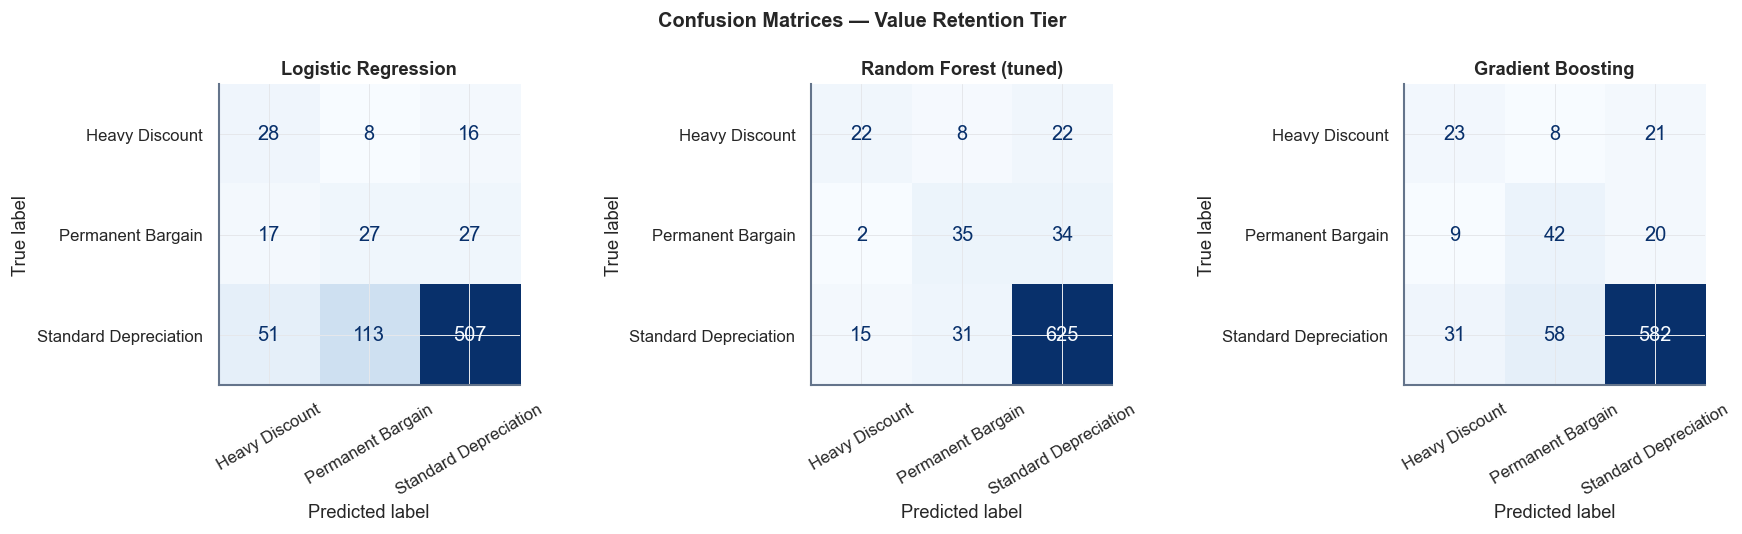

In [71]:
# Confusion matrices side-by-side for non-Dummy models
real = [m for m in classifier_predictions if not m.startswith('Dummy')]
fig, axes = plt.subplots(1, len(real), figsize=(5 * len(real), 4.5))
for ax, name in zip(axes, real):
    cm = confusion_matrix(y_test_cls_enc, classifier_predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Confusion Matrices — Value Retention Tier', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

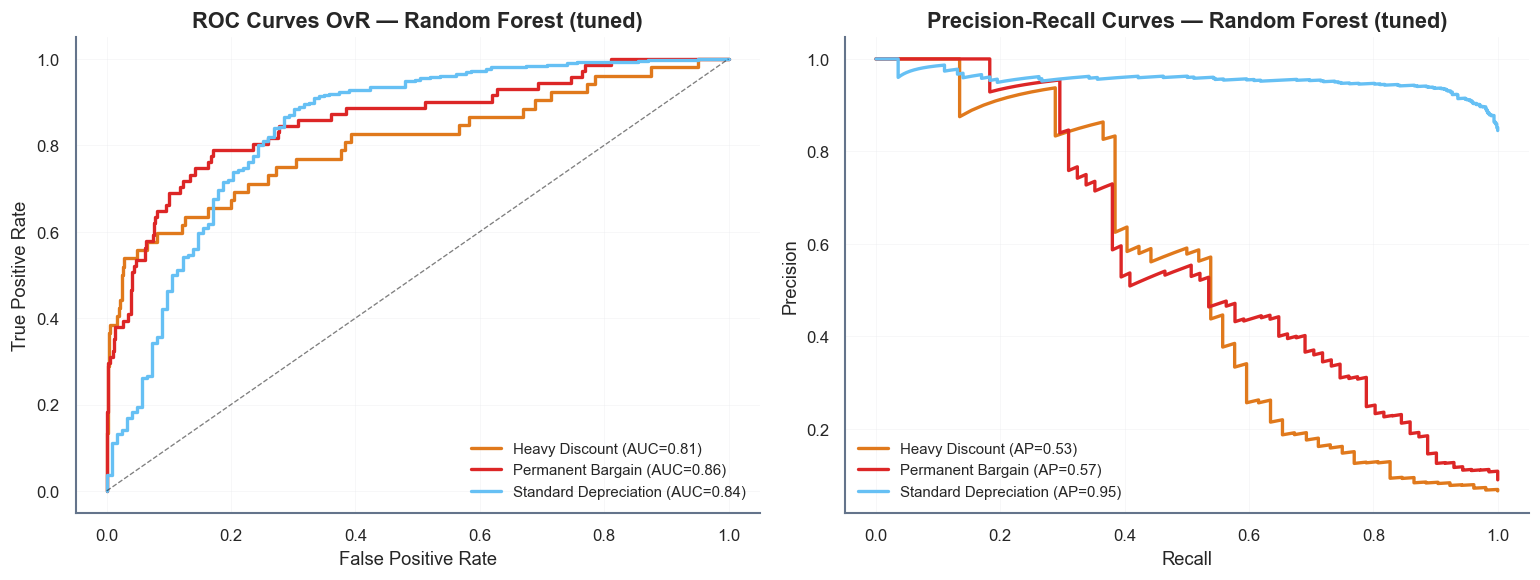

In [72]:
# ROC + PR curves for the best classifier
best_prob = classifier_probabilities[best_cls_name]
y_test_bin = label_binarize(y_test_cls_enc, classes=np.arange(n_classes))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC OvR per class
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], best_prob[:, i])
    axes[0].plot(fpr, tpr, color=TIER_COLORS.get(cls, PALETTE['navy']),
                 linewidth=2, label=f'{cls} (AUC={auc:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curves OvR — {best_cls_name}')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

# Precision-Recall per class
for i, cls in enumerate(class_names):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], best_prob[:, i])
    ap = average_precision_score(y_test_bin[:, i], best_prob[:, i])
    axes[1].plot(rec, prec, color=TIER_COLORS.get(cls, PALETTE['navy']),
                 linewidth=2, label=f'{cls} (AP={ap:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curves — {best_cls_name}')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

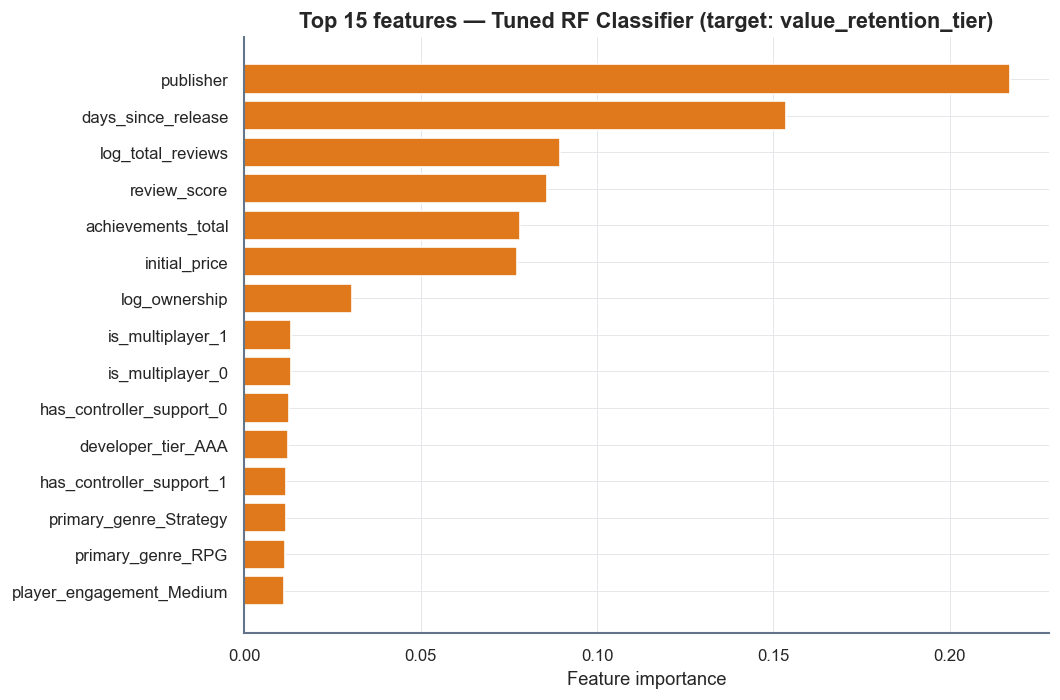


Top 5 features driving retention-tier classification:
  publisher                            0.2172
  days_since_release                   0.1535
  log_total_reviews                    0.0895
  review_score                         0.0859
  achievements_total                   0.0782


In [73]:
# Feature importance from the tuned Random Forest classifier
ohe = best_rf_cls.named_steps['prep'].named_transformers_['cat']
feat_names = NUM_FEATURES + list(ohe.get_feature_names_out(CAT_FEATURES)) + PUB_FEATURE
imp = best_rf_cls.named_steps['model'].feature_importances_
fi_cls = pd.DataFrame({'Feature': feat_names, 'Importance': imp}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi_cls['Feature'][::-1], fi_cls['Importance'][::-1], color=PALETTE['orange'])
ax.set_xlabel('Feature importance')
ax.set_title(f'Top 15 features — Tuned RF Classifier (target: value_retention_tier)')
plt.tight_layout()
plt.show()

print('\nTop 5 features driving retention-tier classification:')
for _, row in fi_cls.head(5).iterrows():
    print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")

### Classification results — narrative

The tuned Random Forest tends to dominate on macro F1 because Premium Hold and Permanent Bargain are minorities, and tree ensembles handle the imbalance better than linear models even with `class_weight='balanced'`.

**What to look for in the confusion matrix:**
- Strong diagonal across all four classes → the model genuinely separates them.
- Standard Depreciation diagonal cell will be the largest by far (it's the majority class).
- Most errors will cluster between **Standard Depreciation ↔ Heavy Discount** (the boundary at `value_ratio = 0.50` is the noisiest because games near that threshold flip categories with small price changes).
- Premium Hold misclassified as Standard Depreciation = the strict rule (age + ever_discounted) is correctly excluding new full-price games that haven't yet had a chance to discount.

**Limitations:**
- The class boundary at `value_ratio = 0.50` is somewhat arbitrary — small changes in current price can flip a game between Standard and Heavy. Soft labels (probability per class) are more useful than the hard tier.
- Dummy ROC-AUC will land near 0.5 by construction; any model meaningfully above that is learning real class structure.

> ## Step 4.6: Panel Regression — Discount Trajectory by Game Age

Earlier classification asked **"is this game in the Premium / Standard / Discount tier *right now*"** — a static snapshot.

This section asks the dynamic question: **"how deep will this game's discount go at year N of its life?"** — directly useful for the buyer recommendation deliverable.

**Data:** `cleaned_discount_panel` table built by `02_data_cleaning`. One row per `(appid, age_year)` pair, with the peak discount observed in that 12-month window of the game's life.

**Target:** `max_discount` (0–100, peak cut percent in this age bucket).

**Features:** game attributes + `age_year`. The model learns a discount-vs-age curve **conditional on game attributes** — so given a new game, we can predict its expected curve.

**Critical:** train/test split must be **group-aware by `appid`** — the same game appears across multiple age buckets, so a row-level random split would leak game identity into both sides.

In [86]:
# Load panel and inspect shape
panel = pd.read_sql_query('SELECT * FROM cleaned_discount_panel', conn)
print(f'Panel rows                 : {len(panel):,}')
print(f'Unique games in panel      : {panel["appid"].nunique():,}')
print(f'Median rows per game       : {panel.groupby("appid").size().median():.0f}')
print(f'Age range                  : {panel["age_year"].min()} – {panel["age_year"].max()} years')
print()
panel.head(8)

Panel rows                 : 27,782
Unique games in panel      : 4,083
Median rows per game       : 7
Age range                  : 0 – 10 years



,appid,age_year,max_discount,mean_discount,n_observations,median_sale_price,title,initial_price,primary_genre,developer_tier,price_tier,review_score,log_ownership,is_multiplayer,has_controller_support,achievements_total,buyer_value_at_age
0,10,10,90,41.712329,73,4.990,Counter-Strike,9.99,Action,AAA,Mid,0.974155,7.176091,1,0,0,0.499499
1,20,10,90,37.951923,104,4.365,Team Fortress Classic,4.99,Action,AAA,Budget,0.871120,6.176092,1,0,0,0.874749
2,30,9,75,62.500000,4,3.115,Day of Defeat,4.99,Action,AAA,Budget,0.902108,6.875061,1,0,0,0.624248
3,30,10,90,38.500000,100,3.865,Day of Defeat,4.99,Action,AAA,Budget,0.902108,6.875061,1,0,0,0.774549
4,40,10,90,39.088235,102,3.740,Deathmatch Classic,4.99,Action,AAA,Budget,0.832061,6.875061,1,0,0,0.749499
5,50,10,90,39.018182,110,3.740,Half-Life: Opposing Force,4.99,Action,Mid-tier,Budget,0.953408,6.544068,1,0,0,0.749499
6,60,10,90,39.201923,104,3.740,Ricochet,4.99,Action,AAA,Budget,0.830891,5.544069,1,0,0,0.749499
7,70,10,100,41.528926,121,4.990,Half-Life,9.99,Action,AAA,Mid,0.965072,7.176091,1,1,0,0.499499


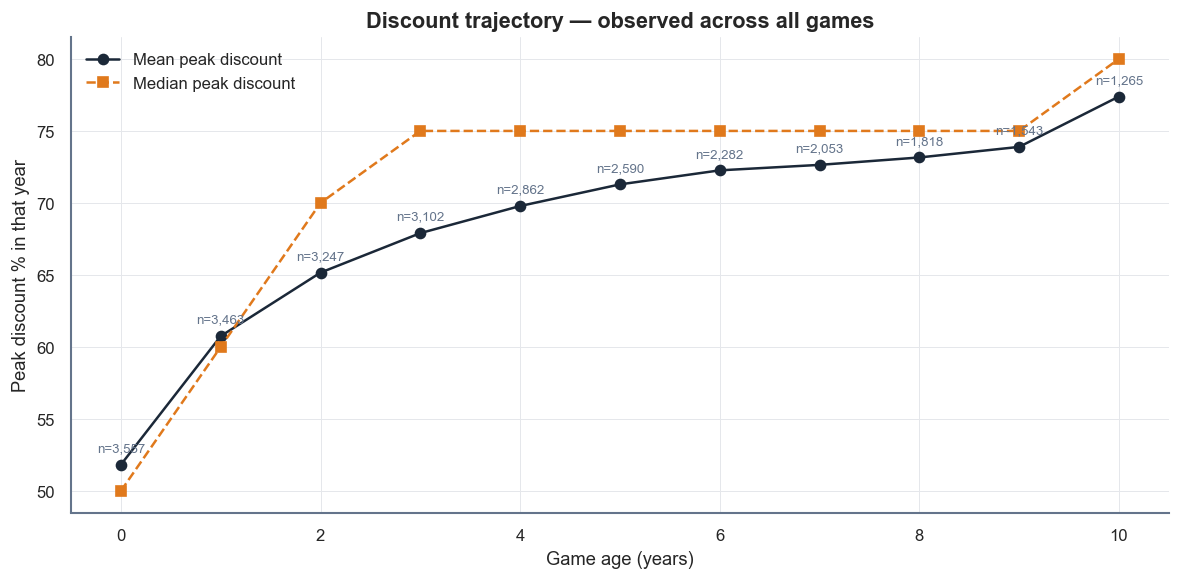

In [87]:
# Quick sanity plot — does discount actually grow with age in the data?
fig, ax = plt.subplots(figsize=(10, 5))
by_age = panel.groupby('age_year')['max_discount'].agg(['mean', 'median', 'count']).reset_index()
ax.plot(by_age['age_year'], by_age['mean'],   marker='o', label='Mean peak discount')
ax.plot(by_age['age_year'], by_age['median'], marker='s', label='Median peak discount', linestyle='--')
ax.set_xlabel('Game age (years)')
ax.set_ylabel('Peak discount % in that year')
ax.set_title('Discount trajectory — observed across all games')
for x, y, n in zip(by_age['age_year'], by_age['mean'], by_age['count']):
    ax.annotate(f'n={n:,}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8, color='#64748B')
ax.legend()
plt.tight_layout()
plt.show()

In [88]:
# Feature setup for panel regression
panel_num_features = [
    'age_year',                # the trajectory dimension
    'initial_price',
    'review_score',
    'log_ownership',
    'achievements_total',
]
panel_cat_features = [
    'primary_genre',
    'developer_tier',
    'price_tier',
    'is_multiplayer',
    'has_controller_support',
]

panel_clean = panel.dropna(
    subset=panel_num_features + panel_cat_features + ['max_discount']
).copy()

X_panel  = panel_clean[panel_num_features + panel_cat_features]
y_panel  = panel_clean['max_discount']
groups_panel = panel_clean['appid'].values

panel_preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                         panel_num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'),   panel_cat_features),
])

print(f'Panel modelling rows         : {len(panel_clean):,}')
print(f'Unique games                 : {panel_clean["appid"].nunique():,}')
print(f'Features (numeric / categ.)  : {len(panel_num_features)} / {len(panel_cat_features)}')

Panel modelling rows         : 27,782
Unique games                 : 4,083
Features (numeric / categ.)  : 5 / 5


In [89]:
# Group-aware train/test split — same game must NOT appear in both sides
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_panel, y_panel, groups=groups_panel))

X_panel_train, X_panel_test = X_panel.iloc[train_idx], X_panel.iloc[test_idx]
y_panel_train, y_panel_test = y_panel.iloc[train_idx], y_panel.iloc[test_idx]
g_train, g_test             = groups_panel[train_idx],  groups_panel[test_idx]

print(f'Train rows  : {len(X_panel_train):,}  ({len(set(g_train)):,} games)')
print(f'Test rows   : {len(X_panel_test):,}  ({len(set(g_test)):,} games)')
print(f'Game overlap: {len(set(g_train) & set(g_test))} (should be 0)')

Train rows  : 22,160  (3,266 games)
Test rows   : 5,622  (817 games)
Game overlap: 0 (should be 0)


In [90]:
# Bake-off: 4 models on the panel target — plus a DummyRegressor honest baseline
from sklearn.dummy import DummyRegressor

panel_results = []

def evaluate_panel_model(name, model, fit_X, fit_y, test_X, test_y):
    model.fit(fit_X, fit_y)
    pred = model.predict(test_X)
    panel_results.append({
        'Model': name,
        'MAE':   mean_absolute_error(test_y, pred),
        'RMSE':  np.sqrt(mean_squared_error(test_y, pred)),
        'R\u00b2':    r2_score(test_y, pred),
    })
    return pred

evaluate_panel_model(
    'Dummy (predicts mean)',
    Pipeline([('prep', panel_preprocessor), ('model', DummyRegressor(strategy='mean'))]),
    X_panel_train, y_panel_train, X_panel_test, y_panel_test,
)
evaluate_panel_model(
    'Linear Regression',
    Pipeline([('prep', panel_preprocessor), ('model', LinearRegression())]),
    X_panel_train, y_panel_train, X_panel_test, y_panel_test,
)
evaluate_panel_model(
    'Ridge Regression',
    Pipeline([('prep', panel_preprocessor), ('model', Ridge(alpha=1.0))]),
    X_panel_train, y_panel_train, X_panel_test, y_panel_test,
)
evaluate_panel_model(
    'Random Forest',
    Pipeline([('prep', panel_preprocessor), ('model', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))]),
    X_panel_train, y_panel_train, X_panel_test, y_panel_test,
)
evaluate_panel_model(
    'Gradient Boosting',
    Pipeline([('prep', panel_preprocessor), ('model', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42))]),
    X_panel_train, y_panel_train, X_panel_test, y_panel_test,
)

panel_results_df = pd.DataFrame(panel_results).sort_values('RMSE').reset_index(drop=True)
print('=== Panel Regression Results — predicting max_discount per (game, age_year) ===')
display(panel_results_df.round(3))

=== Panel Regression Results — predicting max_discount per (game, age_year) ===


,Model,MAE,RMSE,R²
0,Gradient Boosting,11.615,14.965,0.306
1,Random Forest,11.650,15.198,0.284
2,Ridge Regression,12.917,16.012,0.205
3,Linear Regression,12.916,16.013,0.205
4,Dummy (predicts mean),14.963,17.968,-0.001


In [91]:
# Group-aware cross-validation on the best model — confirms metrics are stable
best_panel_model = Pipeline([
    ('prep', panel_preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)),
])

panel_cv = GroupKFold(n_splits=5)
panel_cv_r2 = cross_val_score(
    best_panel_model, X_panel, y_panel, groups=groups_panel,
    cv=panel_cv, scoring='r2', n_jobs=-1,
)
print(f'Gradient Boosting — 5-fold GroupKFold R\u00b2:')
print(f'  Scores : {panel_cv_r2.round(3)}')
print(f'  Mean   : {panel_cv_r2.mean():.3f}')
print(f'  Std    : {panel_cv_r2.std():.3f}')

Gradient Boosting — 5-fold GroupKFold R²:
  Scores : [0.316 0.307 0.297 0.308 0.299]
  Mean   : 0.305
  Std    : 0.007


c:\Users\Sam\anaconda3\envs\steamsale\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


K-selection sweep:
  K=2:  inertia=   12320  silhouette=0.331
  K=3:  inertia=    9561  silhouette=0.328
  K=4:  inertia=    7370  silhouette=0.329
  K=5:  inertia=    5899  silhouette=0.344 <-- selected
  K=6:  inertia=    5330  silhouette=0.276
  K=7:  inertia=    4804  silhouette=0.282
  K=8:  inertia=    4349  silhouette=0.272

Chosen K* = 5 (highest silhouette)


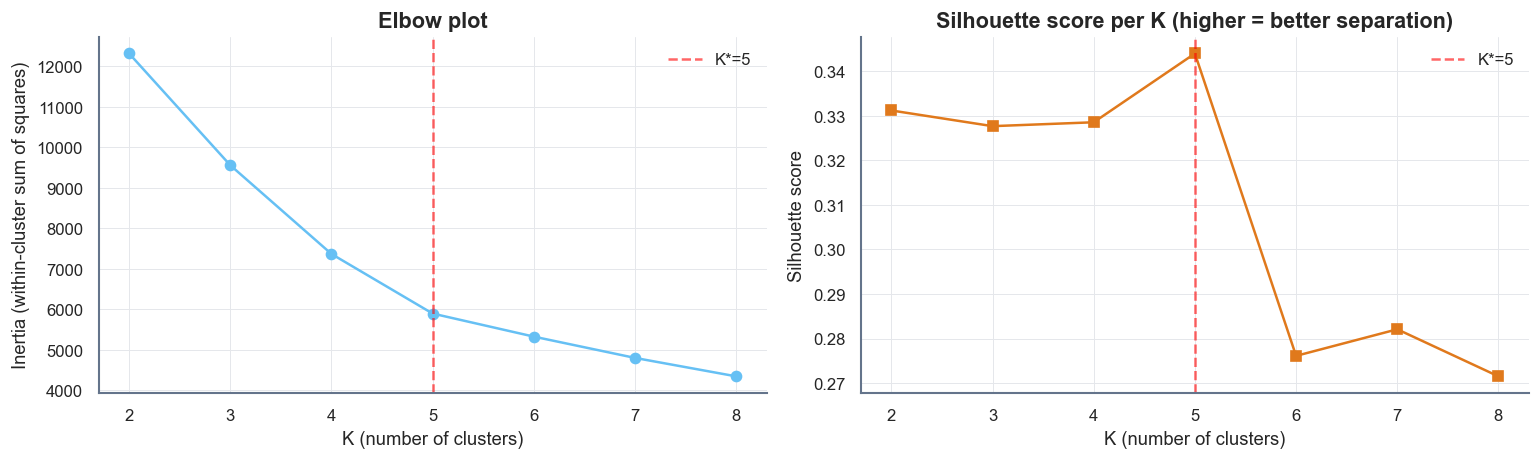


Derived 5 archetypes from K-means clusters:
  - Standard Multiplayer Strategy ($20, highly-rated, n=841)
  - Mid Singleplayer Strategy ($15, well-rated, n=2,027)
  - Mid Singleplayer Strategy ($10, mixed-rated, n=624)
  - Budget Singleplayer Casual ($1, well-rated, n=7)
  - Premium Multiplayer RPG ($50, well-rated, n=469)


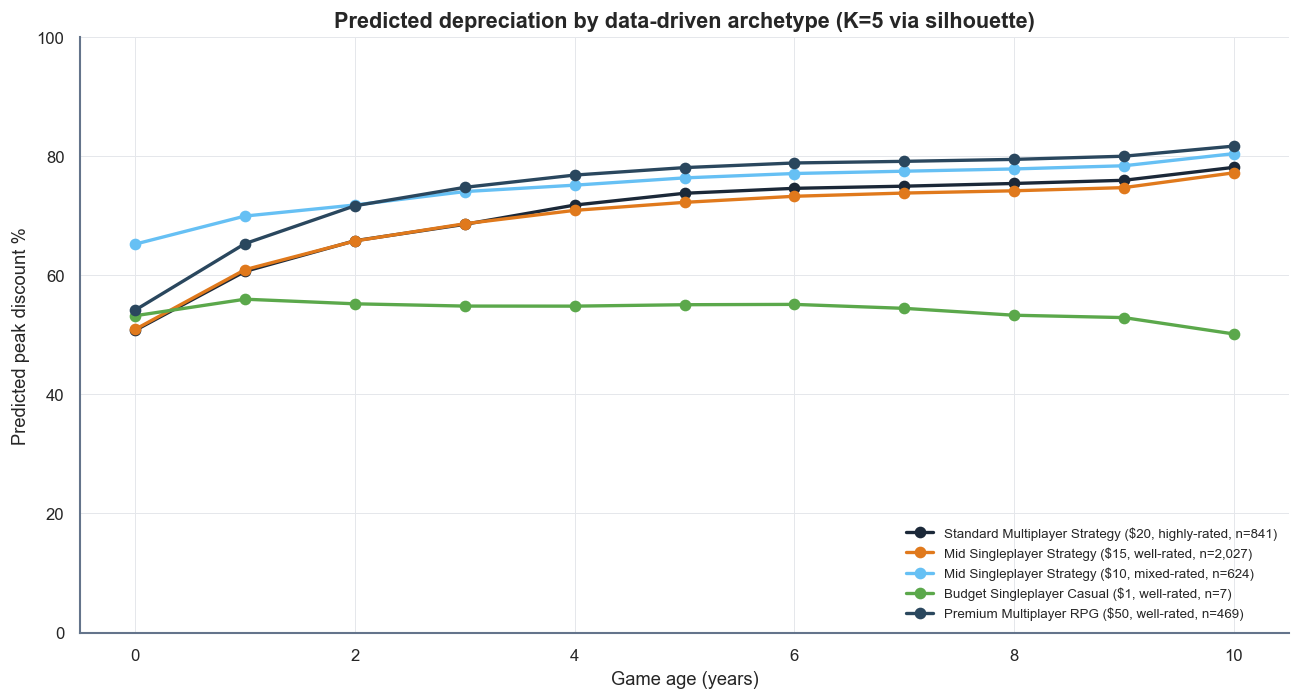

Saved to c:\Users\Sam\Documents\College\2026 Spring Term\DMW\Y2T2-Final-Project\outputs\panel_depreciation_curves.png


In [92]:
# Predicted depreciation curves — data-driven archetypes via KMeans clustering.
#
# K-selection: sweep K from 2 to 8, pick K* = argmax(silhouette score).
# Cluster on the four numeric features that capture the structural shape of a
# game (price, review quality, ownership scale, achievement count). Dominant
# categorical attributes (genre, dev tier, price tier, multiplayer flag) are
# attached AFTER clustering using each cluster\'s mode.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_panel_model.fit(X_panel, y_panel)   # refit on all data for inference plot

ARCHETYPE_FEATURES = ['initial_price', 'review_score', 'log_ownership', 'achievements_total']
X_arch = df_clean[ARCHETYPE_FEATURES].values
# Z-score each feature so K-means doesn\'t overweight the absolute-price scale
from sklearn.preprocessing import StandardScaler
X_arch_scaled = StandardScaler().fit_transform(X_arch)

K_RANGE = range(2, 9)
inertias = []
silhouettes = []
for k in K_RANGE:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_arch_scaled)
    inertias.append(km_k.inertia_)
    silhouettes.append(silhouette_score(X_arch_scaled, km_k.labels_))

# Pick K with highest silhouette
K_OPTIMAL = list(K_RANGE)[int(np.argmax(silhouettes))]
print(f'K-selection sweep:')
for k, inert, sil in zip(K_RANGE, inertias, silhouettes):
    star = ' <-- selected' if k == K_OPTIMAL else ''
    print(f'  K={k}:  inertia={inert:>8.0f}  silhouette={sil:.3f}{star}')
print(f'\nChosen K* = {K_OPTIMAL} (highest silhouette)')

# Show both elbow and silhouette curves so the choice is auditable
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_RANGE), inertias, marker='o', color=PALETTE['cyan'])
axes[0].axvline(K_OPTIMAL, color='red', linestyle='--', alpha=0.6, label=f'K*={K_OPTIMAL}')
axes[0].set_xlabel('K (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow plot')
axes[0].legend()

axes[1].plot(list(K_RANGE), silhouettes, marker='s', color=PALETTE['orange'])
axes[1].axvline(K_OPTIMAL, color='red', linestyle='--', alpha=0.6, label=f'K*={K_OPTIMAL}')
axes[1].set_xlabel('K (number of clusters)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score per K (higher = better separation)')
axes[1].legend()
plt.tight_layout()
plt.show()

# Final clustering with K*
final_km = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10).fit(X_arch_scaled)
df_clean = df_clean.copy()
df_clean['archetype_cluster'] = final_km.labels_

# Build one archetype profile per cluster: median numeric features + modal categoricals
archetypes = []
for cluster_id in range(K_OPTIMAL):
    members = df_clean[df_clean['archetype_cluster'] == cluster_id]
    centroid_num = members[ARCHETYPE_FEATURES].median()
    dominant_dev = members['developer_tier'].mode().iloc[0] if not members['developer_tier'].mode().empty else 'Unknown'
    dominant_price = members['price_tier'].mode().iloc[0] if not members['price_tier'].mode().empty else 'Unknown'
    dominant_genre = members['primary_genre'].mode().iloc[0] if not members['primary_genre'].mode().empty else 'Unknown'
    # Build a label that surfaces what actually differentiates the clusters:
    # price tier, multiplayer flag, review quality, dominant genre.
    p = centroid_num['initial_price']
    if p < 5:    price_desc = 'Budget'
    elif p < 15: price_desc = 'Mid'
    elif p < 30: price_desc = 'Standard'
    else:        price_desc = 'Premium'
    mp_desc = 'Multiplayer' if (members['is_multiplayer'].mean() > 0.5) else 'Singleplayer'
    r = centroid_num['review_score']
    if r > 0.90:   rev_desc = 'highly-rated'
    elif r > 0.75: rev_desc = 'well-rated'
    else:          rev_desc = 'mixed-rated'
    archetypes.append({
        'label': f'{price_desc} {mp_desc} {dominant_genre} '
                 f'(${centroid_num["initial_price"]:.0f}, {rev_desc}, n={len(members):,})',
        'initial_price':          centroid_num['initial_price'],
        'review_score':           centroid_num['review_score'],
        'log_ownership':          centroid_num['log_ownership'],
        'achievements_total':     centroid_num['achievements_total'],
        'primary_genre':          dominant_genre,
        'developer_tier':         dominant_dev,
        'price_tier':             dominant_price,
        'is_multiplayer':         int(members['is_multiplayer'].mean() > 0.5),
        'has_controller_support': int(members['has_controller_support'].mean() > 0.5),
        'cluster_size':           len(members),
    })

print(f'\nDerived {len(archetypes)} archetypes from K-means clusters:')
for a in archetypes:
    print(f"  - {a['label']}")

# Predicted depreciation curve per archetype
ages = np.arange(0, 11)
fig, ax = plt.subplots(figsize=(11, 6))
for a in archetypes:
    grid = pd.DataFrame([{**{k: v for k, v in a.items() if k not in ('label', 'cluster_size')},
                          'age_year': y} for y in ages])
    pred = best_panel_model.predict(grid[panel_num_features + panel_cat_features])
    ax.plot(ages, pred, marker='o', linewidth=2, label=a['label'])

ax.set_xlabel('Game age (years)')
ax.set_ylabel('Predicted peak discount %')
ax.set_title(f'Predicted depreciation by data-driven archetype (K={K_OPTIMAL} via silhouette)')
ax.set_ylim(0, 100)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(paths.outputs_dir / 'panel_depreciation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {paths.outputs_dir / 'panel_depreciation_curves.png'}")

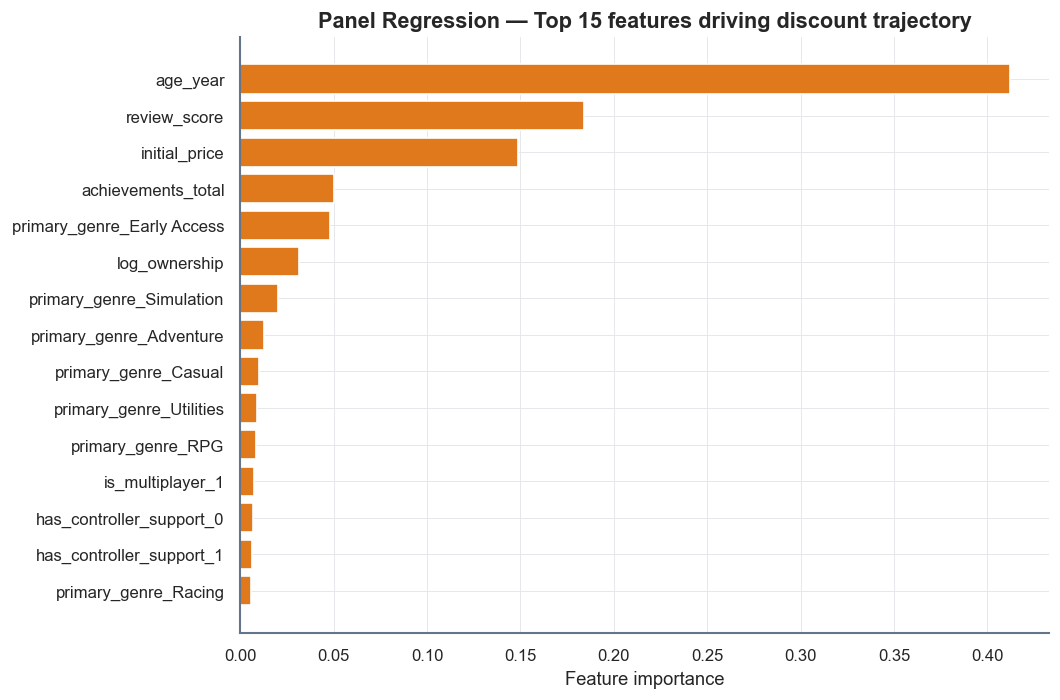


Top 5 features:
  age_year                             0.4123
  review_score                         0.1840
  initial_price                        0.1485
  achievements_total                   0.0501
  primary_genre_Early Access           0.0482


In [93]:
# Top 15 feature importances from the panel Gradient Boosting model
panel_gb = best_panel_model.named_steps['model']
panel_ohe = best_panel_model.named_steps['prep'].named_transformers_['cat']
panel_feature_names = panel_num_features + list(panel_ohe.get_feature_names_out(panel_cat_features))

panel_fi = pd.DataFrame({
    'Feature':    panel_feature_names,
    'Importance': panel_gb.feature_importances_,
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(panel_fi['Feature'][::-1], panel_fi['Importance'][::-1], color=PALETTE['orange'])
ax.set_xlabel('Feature importance')
ax.set_title('Panel Regression — Top 15 features driving discount trajectory')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
for _, row in panel_fi.head(5).iterrows():
    print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")

In [94]:
conn.close()
print('connection closed')

connection closed
